# This is going to be the first iteration of my graphs for my orchestrator

- The first task was to check the win-rate of an agent change as we changed their meta data.
- So we first had ZEN vs GARNET.
- They were my custom AI that would do an action every 6 frames.
- I realized real fast that using wall time was affecting their performance, because in headless mode, time doesn't move the same.
- Hence, we will have 2 graphs, showing headless and visual. They are really the same.

## Agent Settings

- They will do a kick (if in range) every 6 frames, otherwise, they will walk.
- We read their range from their motion data.

### Task

We are going to write something that will fetch the results and graph them plainly

In [49]:
import os
import pathlib
import re

import pandas

import constants as c
import MotionClasses.MotionEditor as me
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as command_names

experiment_name: str = 'orchestra_headless'
simulation_count: int = 10

custom_motion_folder = os.path.join('custom_motions', experiment_name)

motion_diffs = me.get_motion_difference_for_motion(
	me.get_motion_diffs(
		c.CHARACTERS.ZEN,
		[
			me.read_motion_file(motion_file)  #
			for motion_file in pathlib.Path(custom_motion_folder).glob('*.csv')
		],
	),
	command_names.STAND_B,
	headers.ATTACK_HIT_AREA_RIGHT,
)
experiment_regex = re.compile(rf'{re.escape(experiment_name)}_(\d+).*\.csv')

match_results: list[pandas.DataFrame] = []

for experiment_file in pathlib.Path('log/point').glob('*.csv'):
	match = experiment_regex.search(experiment_file.name)

	if match:
		experiment_number = int(match.group(1))
		match_result = pandas.read_csv(
			experiment_file,
			names=[
				c.PointHeaderNames.INSTANCE,
				c.PointHeaderNames.ROUND,
				c.PointHeaderNames.HP_ONE,
				c.PointHeaderNames.HP_TWO,
				c.PointHeaderNames.DRAIN,
				c.PointHeaderNames.WINNER,
			],
			dtype=c.PointHeaderNames.D_TYPE,
		)

		match_result[c.PointHeaderNames.SIMULATION_NUMBER] = experiment_number
		match_result[c.PointHeaderNames.SIMULATION_NUMBER] = match_result[c.PointHeaderNames.SIMULATION_NUMBER].astype('int16')
		match_results.append(match_result)

match_results: pandas.DataFrame = pandas.concat(match_results, ignore_index=True)
match_results.set_index(c.PointHeaderNames.SIMULATION_NUMBER, inplace=True)
match_results = match_results.join(motion_diffs)
match_results.sort_index(inplace=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


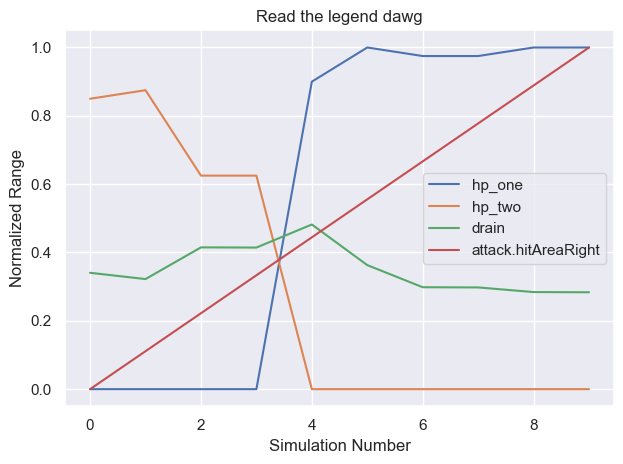

In [52]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import seaborn as sns

import constants as c
import MotionClasses.MotionEditor as me
from MotionClasses.MotionHeaders import MotionHeaders as headers
from MotionClasses.MotionNames import MotionNames as command_names

sns.set_theme(style='darkgrid')

plot_data = match_results.groupby(level=0)[
	[
		c.PointHeaderNames.HP_ONE,
		c.PointHeaderNames.HP_TWO,
		c.PointHeaderNames.DRAIN,
		headers.ATTACK_HIT_AREA_RIGHT,
	]
].mean()

plot_data[c.PointHeaderNames.HP_ONE] /= c.PLAYER_HP
plot_data[c.PointHeaderNames.HP_TWO] /= c.PLAYER_HP
plot_data[c.PointHeaderNames.DRAIN] /= c.GAME_DURATION_SEC * 60
plot_data[headers.ATTACK_HIT_AREA_RIGHT] /= 45


line_plot = sns.lineplot(
	data=plot_data,
	dashes=False,
)

# 3. Finalize labels
line_plot.set_title('Read the legend dawg')
line_plot.set_xlabel('Simulation Number')
line_plot.set_ylabel('Normalized Range')

plt.tight_layout()
plt.show()